Figure 1b–d for Patients 1 and 2.

`DATA` = the `TALL_Review` root (folder that contains `New_Analysis/` and `TALL_Website/`).
These are the current paper ForceAtlas objects.

All ForceAtlas panels use `muon.pl.embedding(..., basis="X_draw_graph_fa", size=100)`.


In [1]:
from pathlib import Path
import numpy as np
import scanpy as sc
import muon
from sklearn.preprocessing import QuantileTransformer

# TALL_Review root: contains New_Analysis/ and TALL_Website/
DATA = Path("PATH_TO_DATA")

# Same marker size on every ForceAtlas. Do not raise dpi or shrink figsize:
# that inflates points on GitHub even when size=100.
sc.set_figure_params(dpi=100, fontsize=12, frameon=False, figsize=(6.4, 4.8))
FA_SIZE = 100


Patient 1 (03H096 / PB2)


In [2]:
adata_mvi = sc.read_h5ad(DATA / "TALL_Website/Object/PB2/Teaseq_Multi_VI_PB2_Cleaned.h5ad")


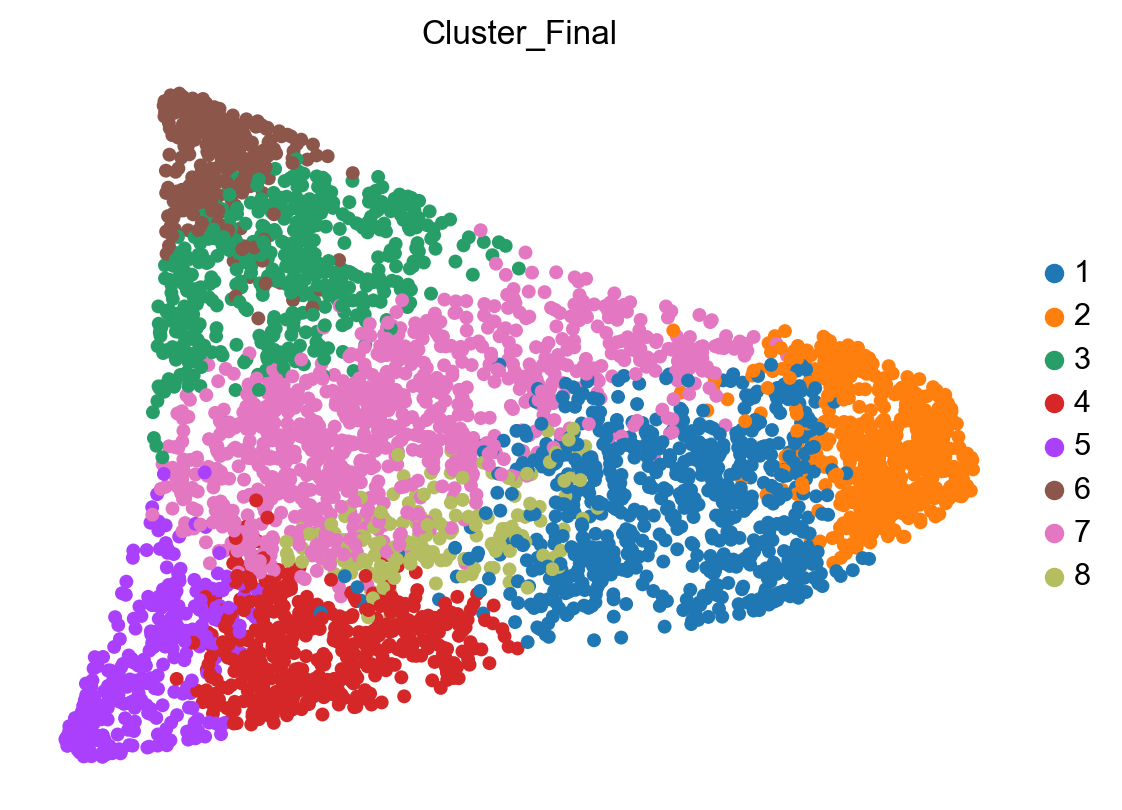

In [3]:
muon.pl.embedding(
    adata_mvi,
    basis="X_draw_graph_fa",
    color=["Cluster_Final"],
    frameon=False,
    ncols=1,
    size=FA_SIZE,
)


/var/folders/96/kkldcmrj3b7c2_99mktnl80r0000gq/T/ipykernel_24202/2898254914.py:34: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(cl):


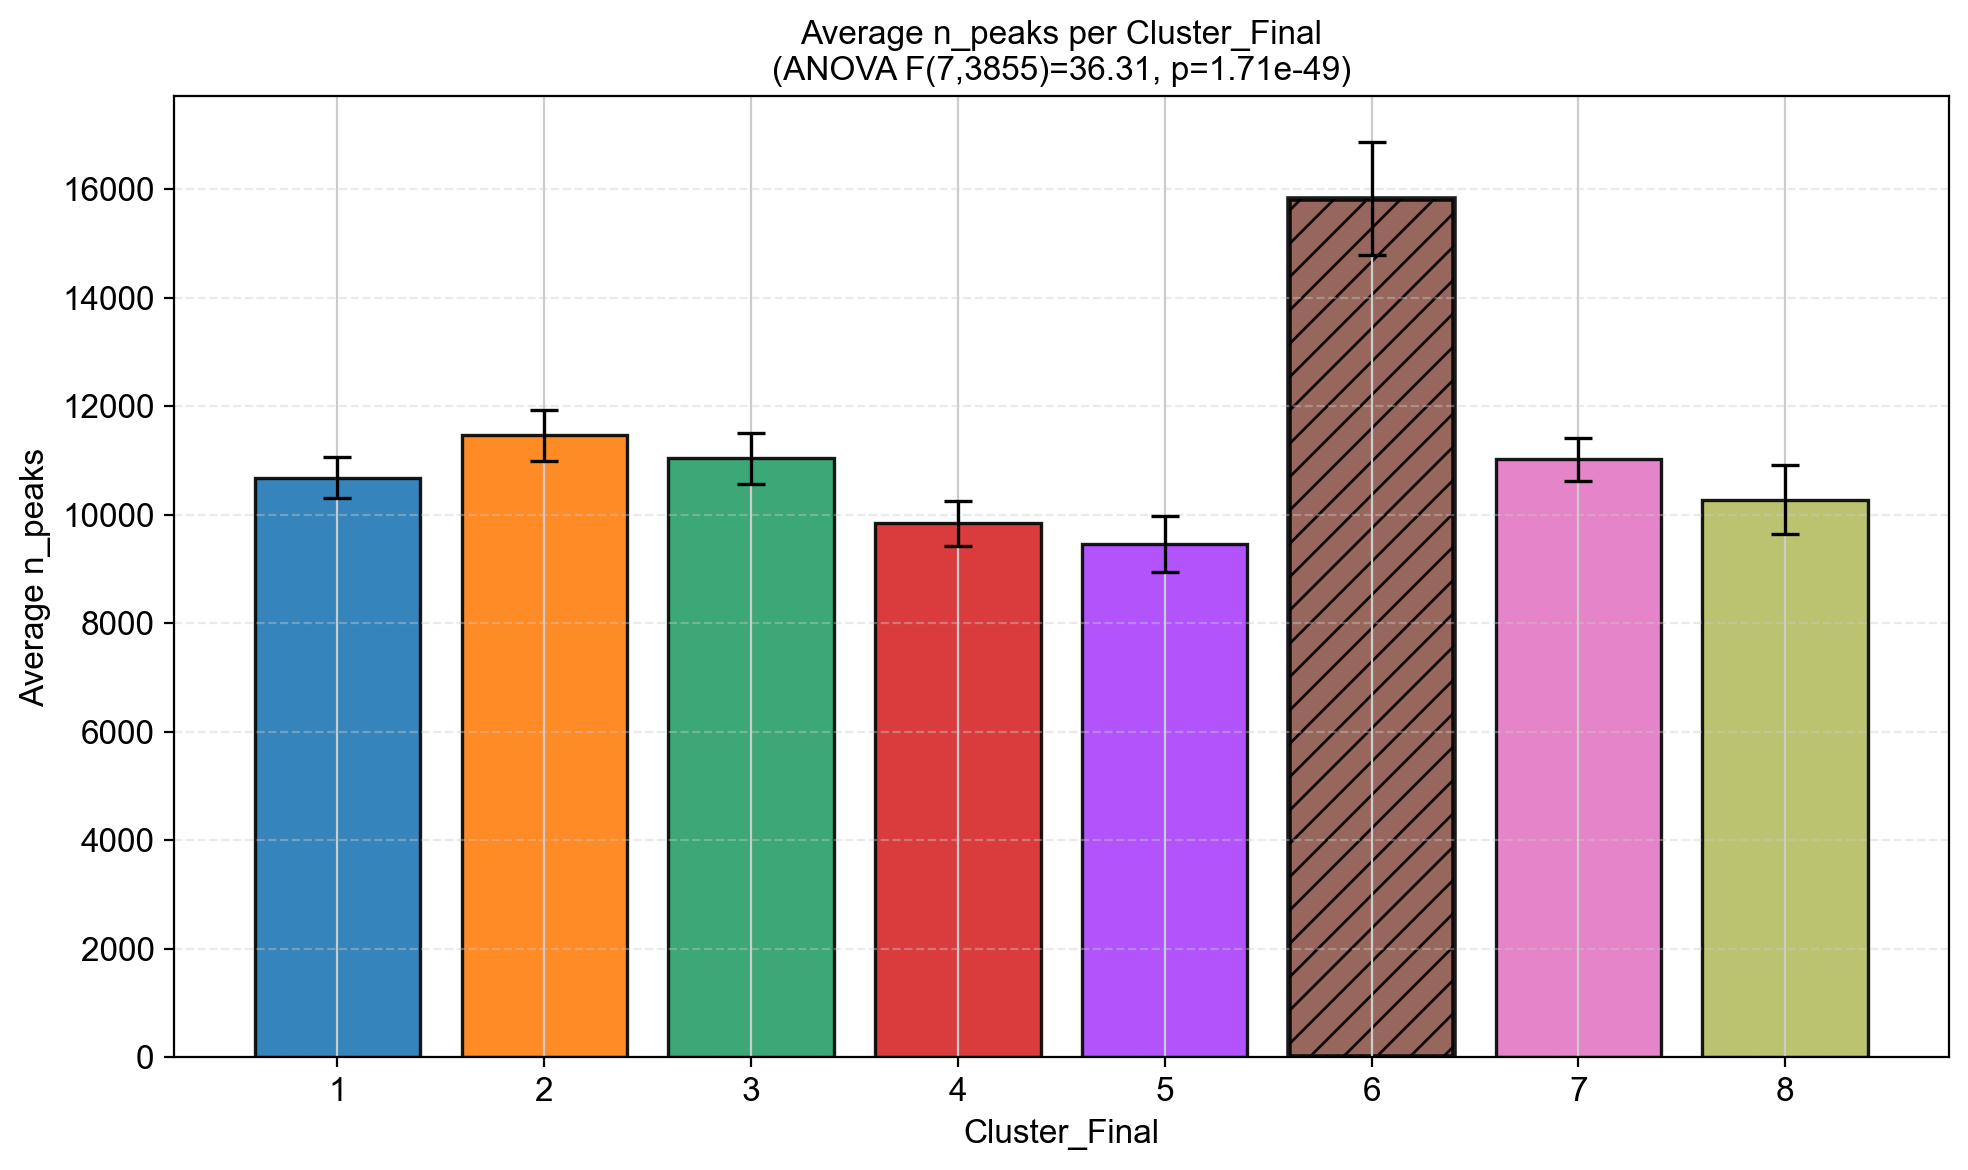


[Summary stats] n_peaks
           Mean  Count          Std         SEM    CI95_Lower    CI95_Upper
1  10682.876990    691  5031.783242  191.418056  10307.697601  11058.056379
2  11460.748515    505  5413.315357  240.889372  10988.605346  11932.891683
3  11037.560575    487  5205.393909  235.878914  10575.237904  11499.883246
4   9841.197339    451  4434.874977  208.830107   9431.890330  10250.504348
5   9464.428571    322  4748.292509  264.611996   8945.789059   9983.068084
6  15825.338078    281  8902.607413  531.085033  14784.411414  16866.264743
7  11023.423442    947  6236.290351  202.652207  10626.225117  11420.621768
8  10277.463687    179  4311.041320  322.222357   9645.907868  10909.019507

[ANOVA] F(7,3855) = 36.3075
[ANOVA] p=1.71e-49
[ANOVA] -log10(p) ≈ 48.77

[Tukey HSD results]
group1 group2   meandiff  p-adj      lower      upper  reject
     1      2   777.8715 0.2695  -228.1671  1783.9101   False
     1      3   354.6836 0.9652  -662.0400  1371.4072   False
     1    

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from scipy.stats import f as fdist
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def _format_p_from_logsf(logp):
    """Readable p-value string from natural log(p)."""
    if not np.isfinite(logp):
        return "p=NA", None
    neglog10p = (-logp) / np.log(10)
    # If p is too small to print in full, report an inequality
    if neglog10p > 300:  # below ~1e-300, show 'p < 1e-XXX'
        return f"p < 1e-{int(np.floor(neglog10p))}", neglog10p
    else:
        p_val = np.exp(logp)
        return f"p={p_val:.2e}", neglog10p

def plot_cluster_openness_with_stats(adata, metric, highlight_max=True):
    """
    Bar plot (mean + 95% CI) of `metric` by Cluster_Final.
    Colors from adata.uns['Cluster_Final_colors'] (one color per category).
    Prints ANOVA and Tukey HSD to the console.
    """
    # Basic checks
    if 'Cluster_Final' not in adata.obs:
        raise KeyError("`Cluster_Final` is missing from adata.obs")
    if metric not in adata.obs:
        raise KeyError(f"`{metric}` is missing from adata.obs")

    # Keep categorical dtype and the exact category order
    cl = adata.obs['Cluster_Final']
    if not pd.api.types.is_categorical_dtype(cl):
        adata.obs['Cluster_Final'] = adata.obs['Cluster_Final'].astype('category')
        cl = adata.obs['Cluster_Final']
    categories = cl.cat.categories

    # Colors
    raw_colors = adata.uns.get('Cluster_Final_colors', None)
    if raw_colors is None:
        raise ValueError("adata.uns['Cluster_Final_colors'] is missing")

    # Convert to a list regardless of type (np.array, tuple, etc.)
    colors = list(raw_colors)

    # Too many colors: keep one per category
    if len(colors) > len(categories):
        colors = colors[:len(categories)]
    if len(colors) < len(categories):
        raise ValueError(
            "Not enough colors in adata.uns['Cluster_Final_colors'] "
            f"(len(colors)={len(colors)}, len(categories)={len(categories)})"
        )

    color_map = {cat: col for cat, col in zip(categories, colors)}

    # Data and numeric coercion
    df = adata.obs[['Cluster_Final', metric]].copy()
    df[metric] = pd.to_numeric(df[metric], errors='coerce')
    df = df.dropna(subset=['Cluster_Final', metric])

    # Keep category order
    df['Cluster_Final'] = df['Cluster_Final'].astype('category')
    df['Cluster_Final'] = df['Cluster_Final'].cat.set_categories(categories, ordered=True)

    # Summary stats
    means  = df.groupby('Cluster_Final', observed=True)[metric].mean().reindex(categories)
    counts = df.groupby('Cluster_Final', observed=True)[metric].count().reindex(categories)
    stds   = df.groupby('Cluster_Final', observed=True)[metric].std().reindex(categories)
    sem    = stds / np.sqrt(counts)
    ci95   = (1.96 * sem).fillna(0.0)

    # ANOVA groups: keep only those with n >= 2
    groups = [df.loc[df['Cluster_Final'] == c, metric].values for c in categories]
    groups_anova = [g for g in groups if len(g) >= 2]
    k = len(groups_anova)
    N = sum(len(g) for g in groups_anova)
    dfn = k - 1
    dfd = N - k

    if k >= 2:
        F, p = f_oneway(*groups_anova)
        logp = fdist.logsf(F, dfn, dfd)  # log(p)
        p_text, neglog10p = _format_p_from_logsf(logp)
        anova_title = f"ANOVA F({dfn},{dfd})={F:.2f}, {p_text}"
    else:
        F, p = np.nan, np.nan
        anova_title = "ANOVA not applicable (need ≥2 groups with n≥2)"

    # Tukey HSD
    tukey = None
    try:
        if df['Cluster_Final'].nunique() >= 2:
            tukey = pairwise_tukeyhsd(df[metric].values, df['Cluster_Final'].values)
    except Exception:
        tukey = None

    # --- Plot: bars + 95% CI ---
    x = np.arange(len(categories))
    fig, ax = plt.subplots(figsize=(10, 6))
    bar_colors = [color_map[cat] for cat in categories]
    bars = ax.bar(
        x,
        means.values,
        yerr=ci95.values,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.9,
        capsize=5,
        error_kw=dict(lw=1.2, capsize=5, capthick=1.2)
    )

    if highlight_max and np.isfinite(means.values).any():
        max_idx = int(np.nanargmax(means.values))
        bars[max_idx].set_hatch("//")
        bars[max_idx].set_linewidth(2.0)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in categories], rotation=0)
    ax.set_xlabel("Cluster_Final")
    ax.set_ylabel(f"Average {metric}")
    ax.set_title(f"Average {metric} per Cluster_Final\n({anova_title})")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # --- Console: summaries + detailed stats ---
    print(f"\n[Summary stats] {metric}")
    summary = pd.DataFrame({
        "Mean": means,
        "Count": counts,
        "Std": stds,
        "SEM": sem,
        "CI95_Lower": means - ci95,
        "CI95_Upper": means + ci95
    })
    print(summary)

    if np.isfinite(F):
        print(f"\n[ANOVA] F({dfn},{dfd}) = {F:.6g}")
        print(f"[ANOVA] {p_text}")
        if 'neglog10p' in locals() and neglog10p is not None:
            print(f"[ANOVA] -log10(p) ≈ {neglog10p:.2f}")
        small = {str(c): len(g) for c, g in zip(categories, groups) if len(g) < 2}
        if len(small):
            print(f"Note: clusters excluded from ANOVA (n<2): {small}")
    else:
        print("\n[ANOVA] Not available")

    if tukey is not None:
        print("\n[Tukey HSD results]")
        tukey_df = pd.DataFrame(
            tukey._results_table.data[1:],
            columns=tukey._results_table.data[0]
        )
        print(tukey_df.to_string(index=False))
    else:
        print("\n[Tukey HSD] Not available")

# Run on the MultiVI object
plot_cluster_openness_with_stats(adata_mvi, "n_peaks")


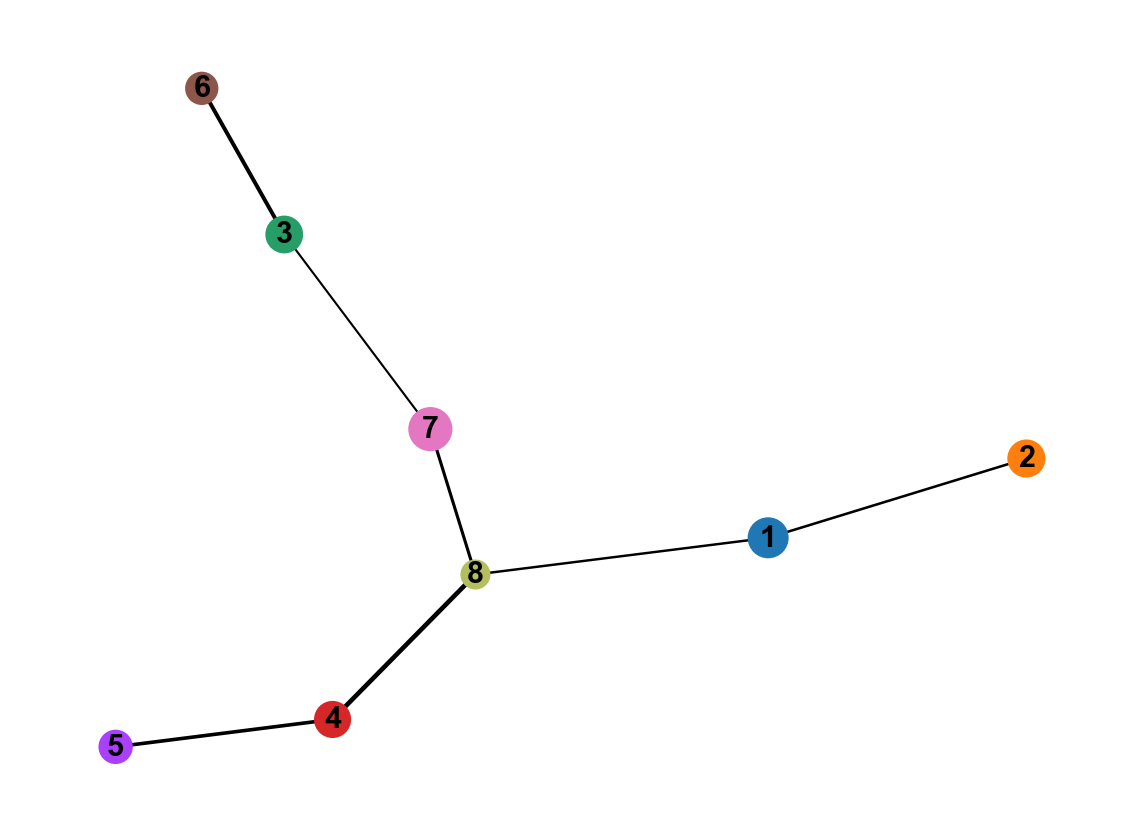

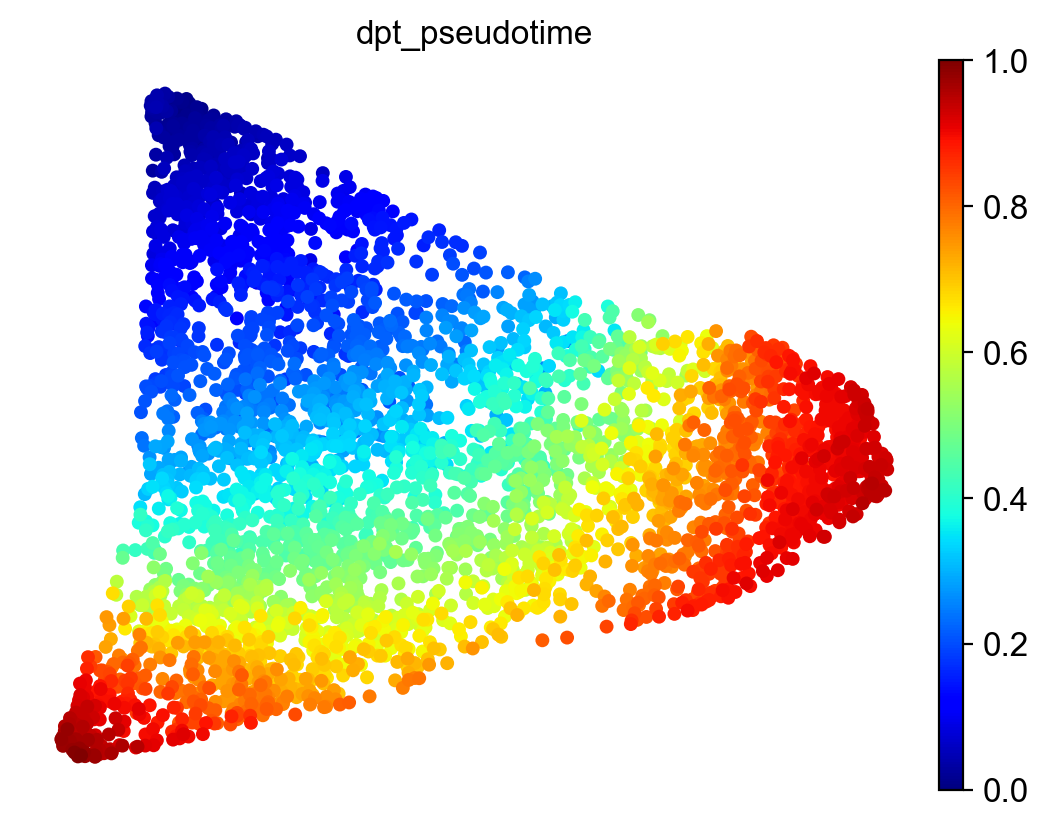

In [5]:
# Copy so PAGA / DPT do not overwrite the object used for the cluster map
adata_mvi = adata_mvi.copy()

# Root = highest mean n_peaks (Patient 1: cluster 6). Same cell as the trajectory notebook.
root_cell = 6
root_index = 2

sc.tl.paga(adata_mvi, groups="Cluster_Final")

cluster_names = adata_mvi.obs["Cluster_Final"].cat.categories
cluster_centers = np.array([
    adata_mvi.obsm["X_draw_graph_fa"][adata_mvi.obs["Cluster_Final"] == cl].mean(axis=0)
    for cl in cluster_names
])
adata_mvi.uns["paga"]["pos"] = cluster_centers

sc.pl.paga(
    adata_mvi,
    color="Cluster_Final",
    pos=adata_mvi.uns["paga"]["pos"],
    threshold=0.3,
    edge_width_scale=0.3,
)

root_indices = np.flatnonzero(adata_mvi.obs["Cluster_Final"].astype(str) == str(root_cell))
if len(root_indices) > root_index:
    adata_mvi.uns["iroot"] = root_indices[root_index]
else:
    print(f"Warning: index {root_index} out of range. Using first cell in cluster {root_cell}.")
    adata_mvi.uns["iroot"] = root_indices[0]

sc.tl.dpt(adata_mvi)

pseudotime = adata_mvi.obs["dpt_pseudotime"].values.reshape(-1, 1)
transformer = QuantileTransformer(n_quantiles=10, random_state=0)
adata_mvi.obs["dpt_pseudotime"] = transformer.fit_transform(pseudotime).flatten()

# Same coordinates and same marker size as the cluster panel above
muon.pl.embedding(
    adata_mvi,
    basis="X_draw_graph_fa",
    color=["dpt_pseudotime"],
    frameon=False,
    ncols=1,
    size=FA_SIZE,
    color_map="jet",
)


Patient 2 (08H125 / PB3)


In [6]:
# Paper Patient 2 = 08H125 / PB3. Figure 1 uses the cleaned MultiVI object (cluster 5 = root).
adata_mvi = sc.read_h5ad(DATA / "New_Analysis/MultiVI/PB3/Teaseq_Multi_VI_PB3_Cleaned.h5ad")


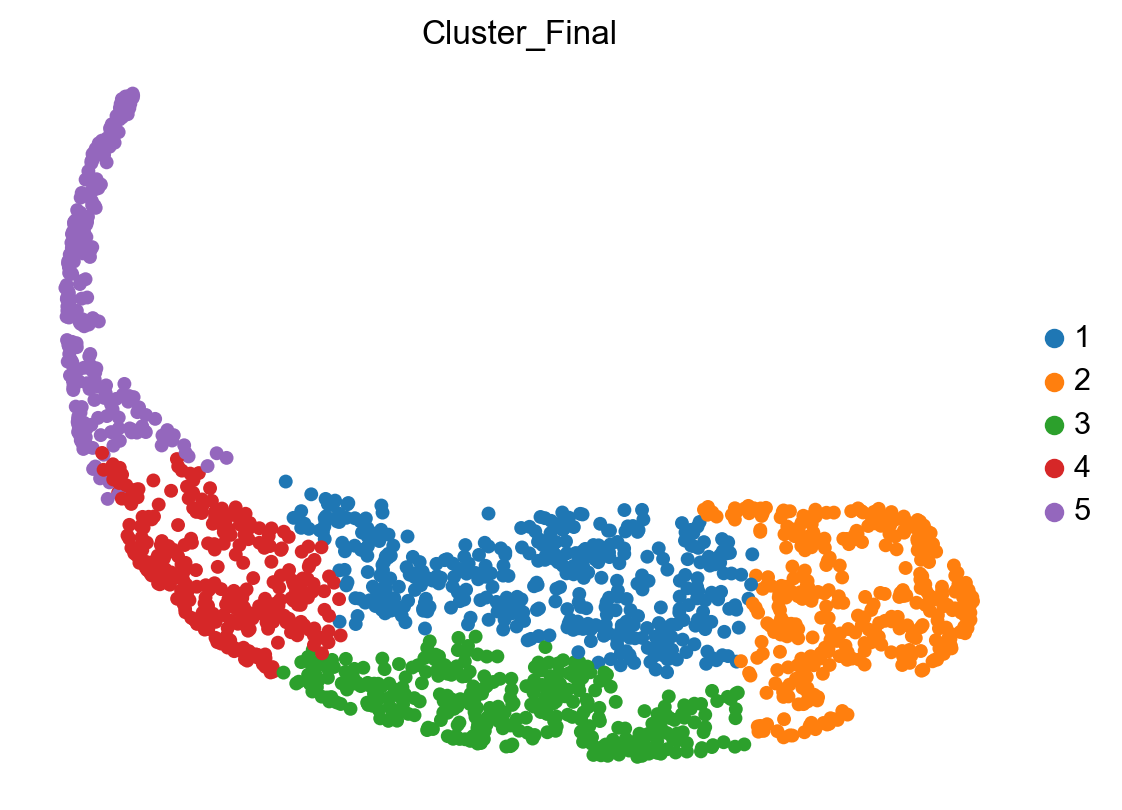

In [7]:
muon.pl.embedding(
    adata_mvi,
    basis="X_draw_graph_fa",
    color=["Cluster_Final"],
    frameon=False,
    ncols=1,
    size=FA_SIZE,
)


/var/folders/96/kkldcmrj3b7c2_99mktnl80r0000gq/T/ipykernel_24202/2898254914.py:34: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(cl):


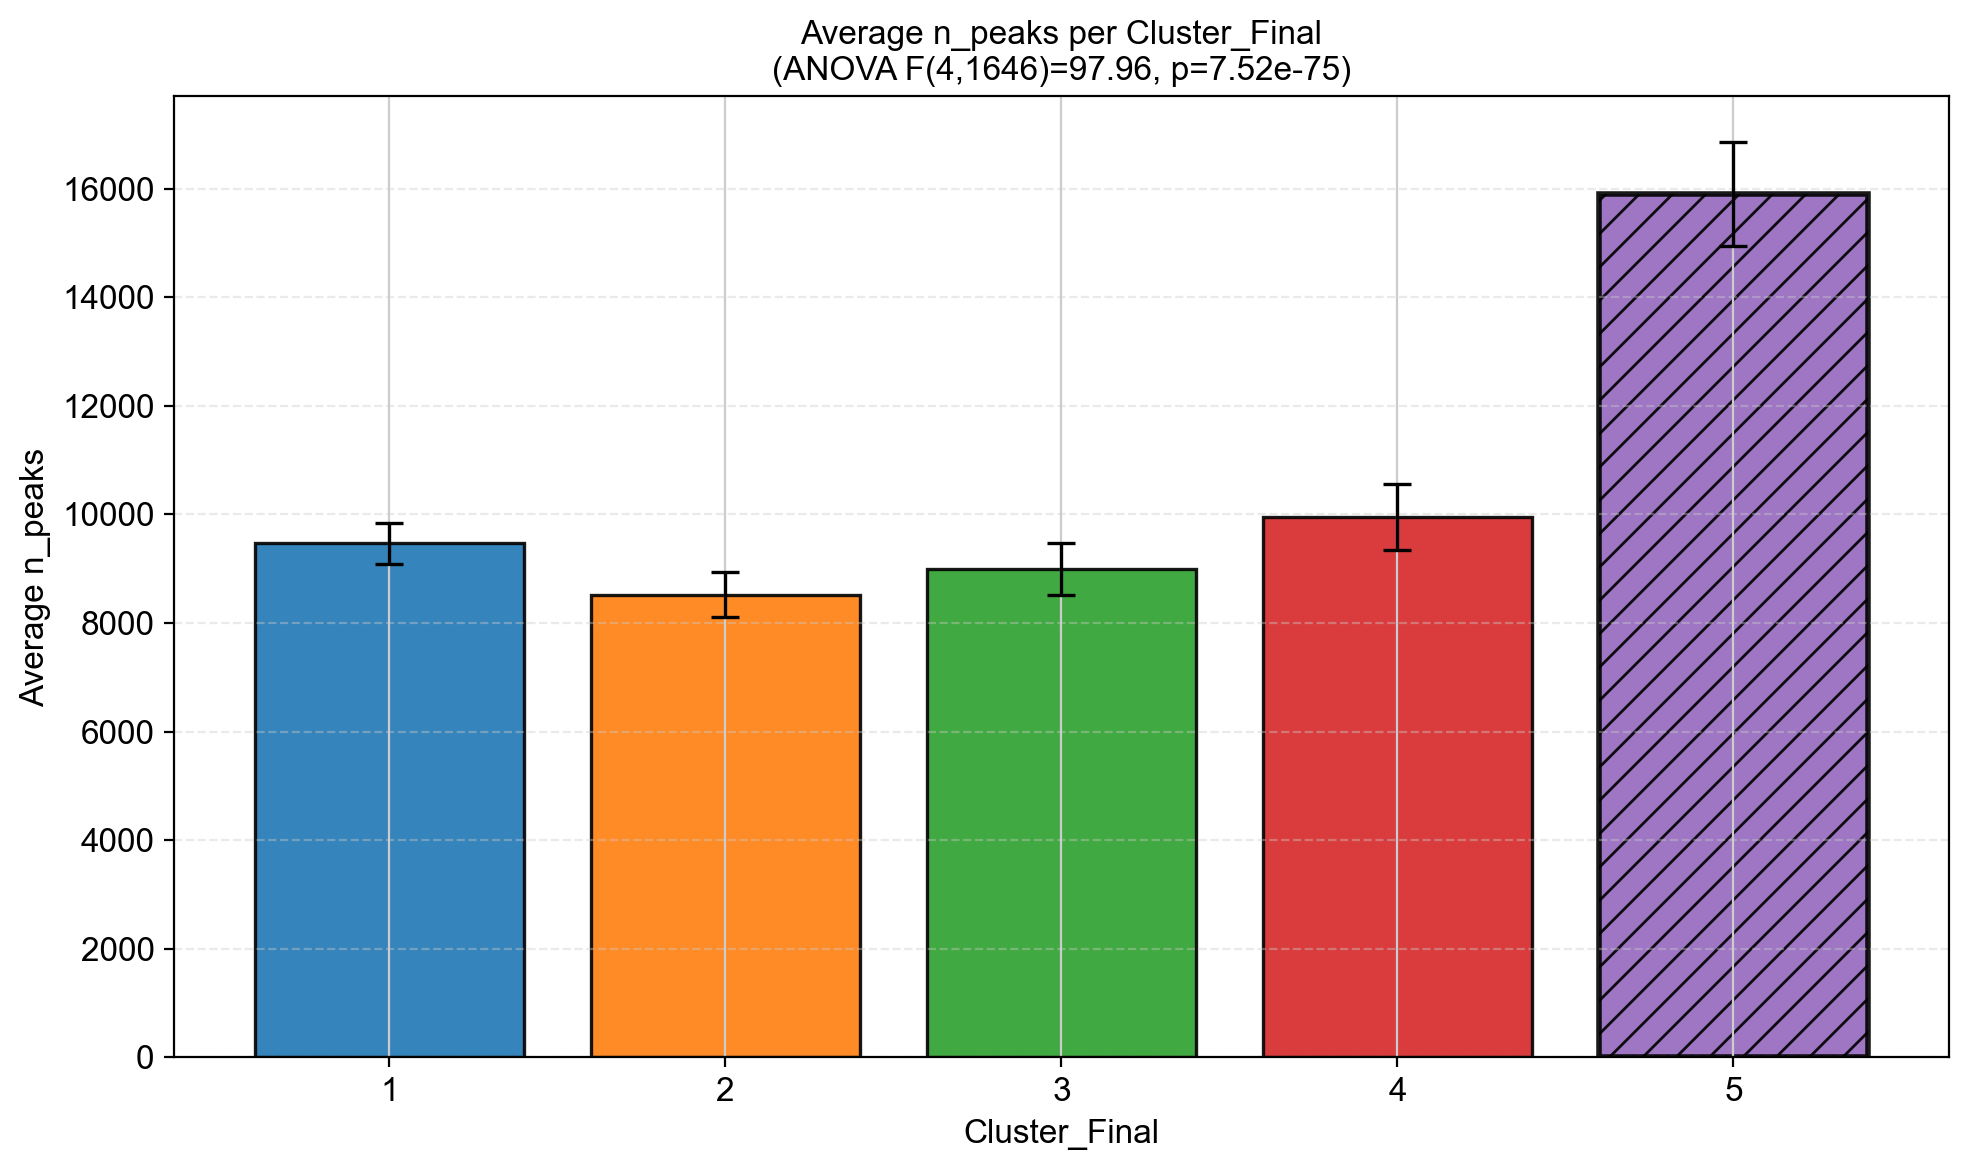


[Summary stats] n_peaks
           Mean  Count          Std         SEM    CI95_Lower    CI95_Upper
1   9469.901367    407  3888.677734  192.754599   9092.102353   9847.700381
2   8522.141602    366  4052.134277  211.808452   8106.997036   8937.286167
3   8992.321289    333  4408.932617  241.608019   8518.769572   9465.873007
4   9954.804688    292  5277.384277  308.835555   9349.487000  10560.122375
5  15897.980469    253  7756.022949  487.616985  14942.251178  16853.709759

[ANOVA] F(4,1646) = 97.9607
[ANOVA] p=7.52e-75
[ANOVA] -log10(p) ≈ 74.12

[Tukey HSD results]
group1 group2  meandiff  p-adj      lower     upper  reject
     1      2 -947.7596 0.0691 -1939.6782   44.1589   False
     1      3 -477.5804 0.7025 -1495.0479  539.8871   False
     1      4  484.9031 0.7195  -571.1214 1540.9276   False
     1      5 6428.0785 0.0000  5325.6802 7530.4768    True
     2      3  470.1792 0.7331  -572.6182 1512.9767   False
     2      4 1432.6627 0.0028   352.2119 2513.1135    True
    

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
from scipy.stats import f as fdist
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def _format_p_from_logsf(logp):
    """Readable p-value string from natural log(p)."""
    if not np.isfinite(logp):
        return "p=NA", None
    neglog10p = (-logp) / np.log(10)
    # If p is too small to print in full, report an inequality
    if neglog10p > 300:  # below ~1e-300, show 'p < 1e-XXX'
        return f"p < 1e-{int(np.floor(neglog10p))}", neglog10p
    else:
        p_val = np.exp(logp)
        return f"p={p_val:.2e}", neglog10p

def plot_cluster_openness_with_stats(adata, metric, highlight_max=True):
    """
    Bar plot (mean + 95% CI) of `metric` by Cluster_Final.
    Colors from adata.uns['Cluster_Final_colors'] (one color per category).
    Prints ANOVA and Tukey HSD to the console.
    """
    # Basic checks
    if 'Cluster_Final' not in adata.obs:
        raise KeyError("`Cluster_Final` is missing from adata.obs")
    if metric not in adata.obs:
        raise KeyError(f"`{metric}` is missing from adata.obs")

    # Keep categorical dtype and the exact category order
    cl = adata.obs['Cluster_Final']
    if not pd.api.types.is_categorical_dtype(cl):
        adata.obs['Cluster_Final'] = adata.obs['Cluster_Final'].astype('category')
        cl = adata.obs['Cluster_Final']
    categories = cl.cat.categories

    # Colors
    raw_colors = adata.uns.get('Cluster_Final_colors', None)
    if raw_colors is None:
        raise ValueError("adata.uns['Cluster_Final_colors'] is missing")

    # Convert to a list regardless of type (np.array, tuple, etc.)
    colors = list(raw_colors)

    # Too many colors: keep one per category
    if len(colors) > len(categories):
        colors = colors[:len(categories)]
    if len(colors) < len(categories):
        raise ValueError(
            "Not enough colors in adata.uns['Cluster_Final_colors'] "
            f"(len(colors)={len(colors)}, len(categories)={len(categories)})"
        )

    color_map = {cat: col for cat, col in zip(categories, colors)}

    # Data and numeric coercion
    df = adata.obs[['Cluster_Final', metric]].copy()
    df[metric] = pd.to_numeric(df[metric], errors='coerce')
    df = df.dropna(subset=['Cluster_Final', metric])

    # Keep category order
    df['Cluster_Final'] = df['Cluster_Final'].astype('category')
    df['Cluster_Final'] = df['Cluster_Final'].cat.set_categories(categories, ordered=True)

    # Summary stats
    means  = df.groupby('Cluster_Final', observed=True)[metric].mean().reindex(categories)
    counts = df.groupby('Cluster_Final', observed=True)[metric].count().reindex(categories)
    stds   = df.groupby('Cluster_Final', observed=True)[metric].std().reindex(categories)
    sem    = stds / np.sqrt(counts)
    ci95   = (1.96 * sem).fillna(0.0)

    # ANOVA groups: keep only those with n >= 2
    groups = [df.loc[df['Cluster_Final'] == c, metric].values for c in categories]
    groups_anova = [g for g in groups if len(g) >= 2]
    k = len(groups_anova)
    N = sum(len(g) for g in groups_anova)
    dfn = k - 1
    dfd = N - k

    if k >= 2:
        F, p = f_oneway(*groups_anova)
        logp = fdist.logsf(F, dfn, dfd)  # log(p)
        p_text, neglog10p = _format_p_from_logsf(logp)
        anova_title = f"ANOVA F({dfn},{dfd})={F:.2f}, {p_text}"
    else:
        F, p = np.nan, np.nan
        anova_title = "ANOVA not applicable (need ≥2 groups with n≥2)"

    # Tukey HSD
    tukey = None
    try:
        if df['Cluster_Final'].nunique() >= 2:
            tukey = pairwise_tukeyhsd(df[metric].values, df['Cluster_Final'].values)
    except Exception:
        tukey = None

    # --- Plot: bars + 95% CI ---
    x = np.arange(len(categories))
    fig, ax = plt.subplots(figsize=(10, 6))
    bar_colors = [color_map[cat] for cat in categories]
    bars = ax.bar(
        x,
        means.values,
        yerr=ci95.values,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.9,
        capsize=5,
        error_kw=dict(lw=1.2, capsize=5, capthick=1.2)
    )

    if highlight_max and np.isfinite(means.values).any():
        max_idx = int(np.nanargmax(means.values))
        bars[max_idx].set_hatch("//")
        bars[max_idx].set_linewidth(2.0)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in categories], rotation=0)
    ax.set_xlabel("Cluster_Final")
    ax.set_ylabel(f"Average {metric}")
    ax.set_title(f"Average {metric} per Cluster_Final\n({anova_title})")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # --- Console: summaries + detailed stats ---
    print(f"\n[Summary stats] {metric}")
    summary = pd.DataFrame({
        "Mean": means,
        "Count": counts,
        "Std": stds,
        "SEM": sem,
        "CI95_Lower": means - ci95,
        "CI95_Upper": means + ci95
    })
    print(summary)

    if np.isfinite(F):
        print(f"\n[ANOVA] F({dfn},{dfd}) = {F:.6g}")
        print(f"[ANOVA] {p_text}")
        if 'neglog10p' in locals() and neglog10p is not None:
            print(f"[ANOVA] -log10(p) ≈ {neglog10p:.2f}")
        small = {str(c): len(g) for c, g in zip(categories, groups) if len(g) < 2}
        if len(small):
            print(f"Note: clusters excluded from ANOVA (n<2): {small}")
    else:
        print("\n[ANOVA] Not available")

    if tukey is not None:
        print("\n[Tukey HSD results]")
        tukey_df = pd.DataFrame(
            tukey._results_table.data[1:],
            columns=tukey._results_table.data[0]
        )
        print(tukey_df.to_string(index=False))
    else:
        print("\n[Tukey HSD] Not available")

# Run on the MultiVI object
plot_cluster_openness_with_stats(adata_mvi, "n_peaks")


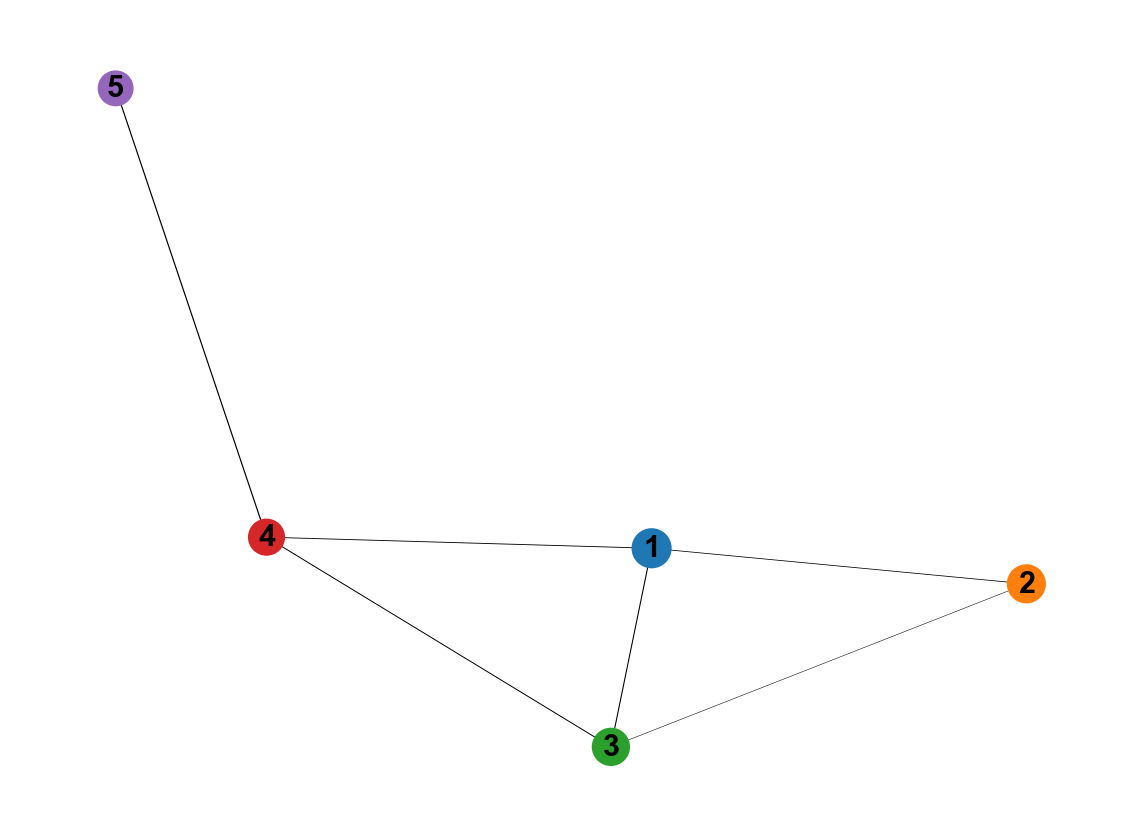

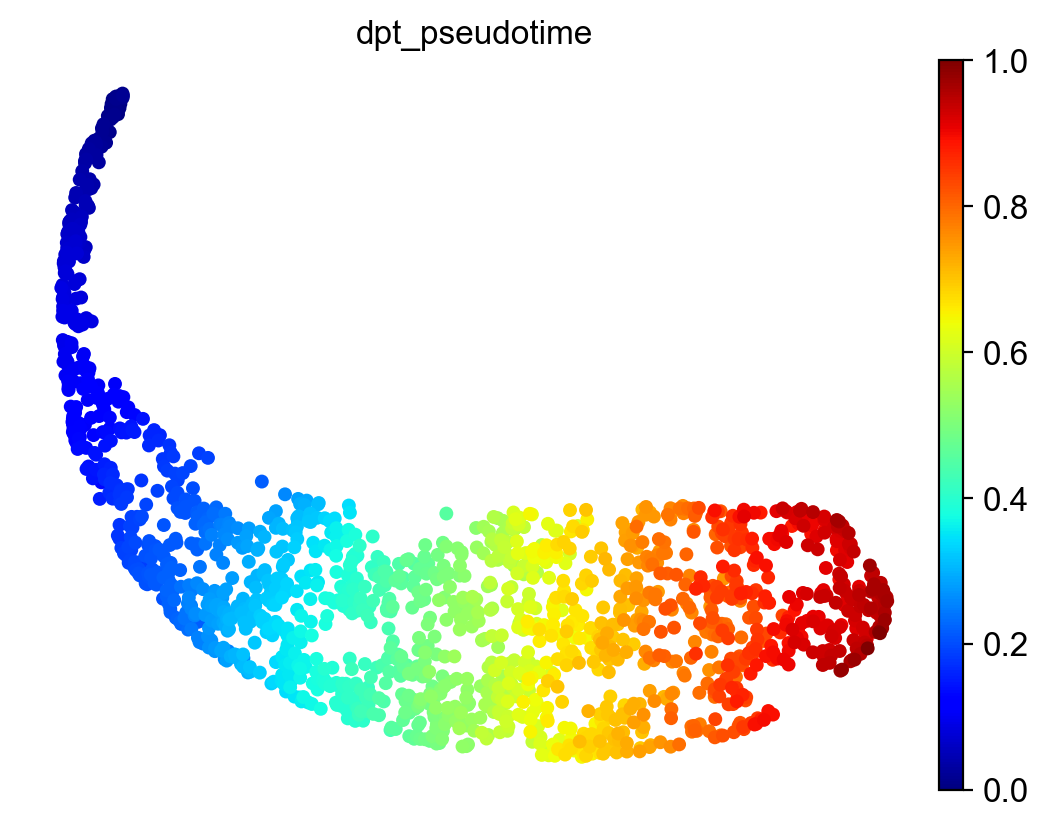

In [9]:
# Copy so PAGA / DPT do not overwrite the object used for the cluster map
adata_mvi = adata_mvi.copy()

# Root = highest mean n_peaks (paper Figure 1: Patient 2 cluster 5).
root_cell = 5
root_index = 0

sc.tl.paga(adata_mvi, groups="Cluster_Final")

cluster_names = adata_mvi.obs["Cluster_Final"].cat.categories
cluster_centers = np.array([
    adata_mvi.obsm["X_draw_graph_fa"][adata_mvi.obs["Cluster_Final"] == cl].mean(axis=0)
    for cl in cluster_names
])
adata_mvi.uns["paga"]["pos"] = cluster_centers

sc.pl.paga(
    adata_mvi,
    color="Cluster_Final",
    pos=adata_mvi.uns["paga"]["pos"],
    edge_width_scale=0.3,
)

root_indices = np.flatnonzero(adata_mvi.obs["Cluster_Final"].astype(str) == str(root_cell))
if len(root_indices) > root_index:
    adata_mvi.uns["iroot"] = root_indices[root_index]
else:
    print(f"Warning: index {root_index} out of range. Using first cell in cluster {root_cell}.")
    adata_mvi.uns["iroot"] = root_indices[0]

sc.tl.dpt(adata_mvi)

pseudotime = adata_mvi.obs["dpt_pseudotime"].values.reshape(-1, 1)
transformer = QuantileTransformer(n_quantiles=10, random_state=0)
adata_mvi.obs["dpt_pseudotime"] = transformer.fit_transform(pseudotime).flatten()

# Same coordinates and same marker size as the cluster panel above
muon.pl.embedding(
    adata_mvi,
    basis="X_draw_graph_fa",
    color=["dpt_pseudotime"],
    frameon=False,
    ncols=1,
    size=FA_SIZE,
    color_map="jet",
)
